# 📊 Retail Sales Forecasting using SARIMA

## 📌 Project Objective
This project aims to forecast future retail sales using historical Superstore data and time-series forecasting techniques. The analysis focuses on identifying sales trends, seasonality, and generating future sales predictions using the SARIMA model.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [50]:
df = pd.read_excel("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 3/sample_-_superstore.xlsx")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 🧹 Data Cleaning
### Purpose: 
Before building the forecasting model, the dataset is cleaned and prepared by:
- converting Order Date into datetime format
- sorting records chronologically
- checking missing values

Proper preprocessing ensures accurate time-series analysis.

In [55]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
# Sort data by date
df = df.sort_values('Order Date')
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## 📈 Monthly Sales Aggregation
### Purpose

The original transactional dataset is converted into monthly sales data using the Order Date column.

This transformation helps create a time-series dataset suitable for forecasting models like SARIMA.

In [56]:
monthly_sales = df.resample('M',on='Order Date')['Sales'].sum()
print("\nMonthly Sales:")
print(monthly_sales.head())


Monthly Sales:
Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_6312\1323742667.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M',on='Order Date')['Sales'].sum()


## 📊 Monthly Sales Trend Visualization
### Purpose: 
The monthly sales trend is visualized to understand:

- overall sales growth
- fluctuations over time
- possible seasonal patterns

This helps identify whether forecasting techniques are appropriate for the dataset.

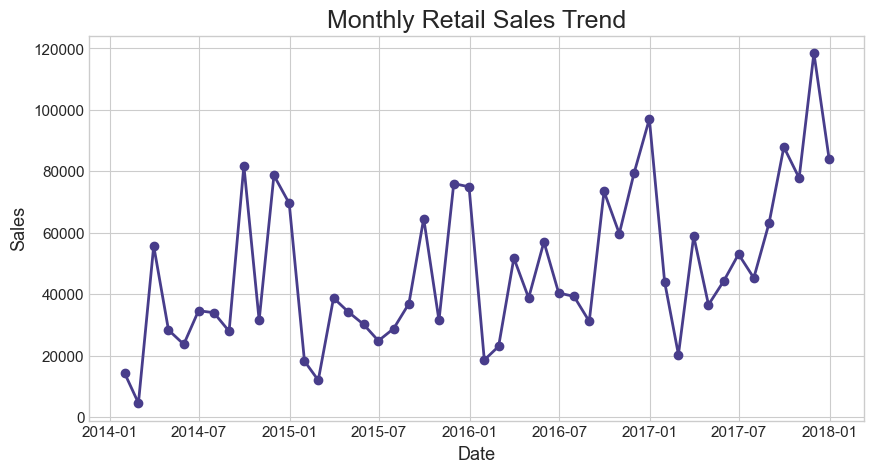

In [197]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, marker='o',linewidth=2, color='darkslateblue')
plt.title("Monthly Retail Sales Trend",fontsize=18)
plt.xlabel("Date",fontsize=13)
plt.ylabel("Sales",fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(alpha=1)
plt.show()

## 🔍 Time-Series Decomposition
### Purpose

Time-series decomposition separates the sales data into:

- Trend
- Seasonality
- Residual components

This analysis helps understand hidden patterns within the sales data and confirms the presence of seasonality.

“Time series decomposition was performed to identify trend and seasonal patterns in monthly sales data before building forecasting models.”

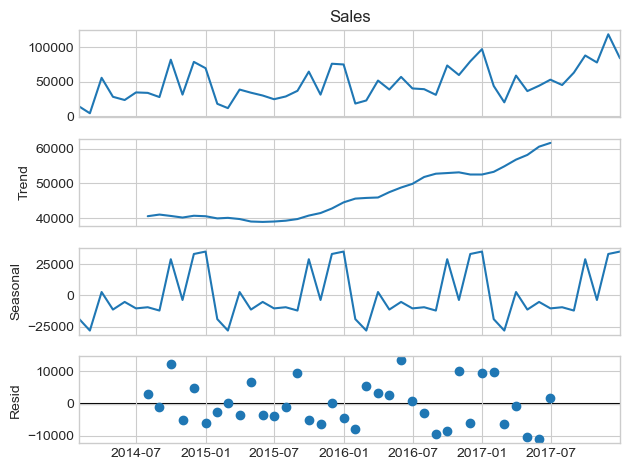

In [142]:
decompose = seasonal_decompose(monthly_sales, model='additive')
decompose.plot()
plt.show()

## ✂️ Train-Test Split
### Purpose

The dataset is divided into training and testing sets:

- Training data is used to build the forecasting model
- Testing data is used to evaluate prediction accuracy

This helps measure how well the model performs on unseen data.

In [59]:
train_size = int(len(monthly_sales) * 0.8)
train = monthly_sales[:train_size]
test = monthly_sales[train_size:]
print("\nTrain Size:", len(train))
print("Test Size:", len(test))


Train Size: 38
Test Size: 10


## 🤖 SARIMA Model Building
### Purpose

A SARIMA model is implemented to capture:

- long-term sales trends
- seasonal sales behavior
- fluctuations in retail demand

In [104]:
model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12))
model_fit = model.fit()
# Print summary
print(model_fit.summary())

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                   38
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -269.961
Date:                              Sat, 16 May 2026   AIC                            553.923
Time:                                      23:31:07   BIC                            562.455
Sample:                                  01-31-2014   HQIC                           556.289
                                       - 02-28-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1322      0.311     -0.425      0.671      -0.742       0.478
ar.L2          0.51

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 📉 Sales Prediction
### Purpose

The trained SARIMA model is used to generate predictions for the testing dataset.

Predicted sales values are compared with actual sales values to evaluate forecasting performance.

In [105]:
predictions = model_fit.forecast(steps=len(test))
predictions.index = test.index
print(predictions)

Order Date
2017-03-31     54657.425087
2017-04-30     45975.825898
2017-05-31     60289.725193
2017-06-30     49928.635860
2017-07-31     50994.811475
2017-08-31     46619.598512
2017-09-30     85901.037382
2017-10-31     66797.020635
2017-11-30     92366.333111
2017-12-31    103628.395991
Freq: ME, Name: predicted_mean, dtype: float64


## 📏 Model Evaluation
### Purpose

The forecasting model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

These metrics measure how close the predicted sales values are to actual sales.

Lower values indicate better model performance.

In [106]:
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print("\nModel Evaluation")
results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae, rmse]
})
print(results)


Model Evaluation
  Metric         Value
0    MAE  11380.869357
1   RMSE  13693.745406


Your average prediction error is now: ~11k sales units
Considering monthly sales are around: 30k–60k+
this is a reasonable forecasting performance.

## Actual vs Predicted Visualization
### Purpose

This visualization compares:

- actual sales values
- predicted sales values

It helps visually evaluate how accurately the SARIMA model captured sales patterns.

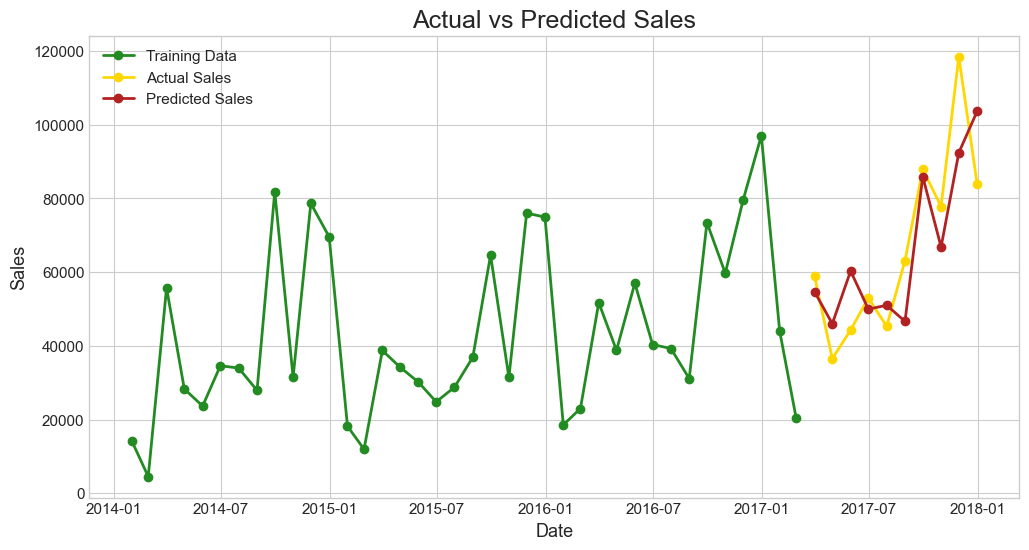

In [198]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data', marker='o',linewidth=2, color= 'forestgreen')
plt.plot(test.index, test, label='Actual Sales', marker='o',linewidth=2,color='gold')
plt.plot(test.index, predictions, label='Predicted Sales', marker='o',linewidth=2, color='firebrick')
plt.title("Actual vs Predicted Sales", fontsize=18)
plt.xlabel("Date",fontsize=13)
plt.ylabel("Sales",fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)
plt.grid(alpha=1)
plt.show()

## 🔮 Future Sales Forecasting
### Purpose

The trained SARIMA model is used to forecast future sales for upcoming months.

This helps estimate future business performance and supports data-driven decision-making.

In [126]:
final_model = SARIMAX(monthly_sales,
                      order=(2,1,2),
                      seasonal_order=(1,1,1,12))

final_model_fit = final_model.fit()
future_forecast = final_model_fit.forecast(steps=6)
print("\nFuture Forecast:")
print(future_forecast)

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



Future Forecast:
2018-01-31    43663.032214
2018-02-28    25531.736411
2018-03-31    54361.005842
2018-04-30    50039.398978
2018-05-31    44819.151063
2018-06-30    56147.905400
Freq: ME, Name: predicted_mean, dtype: float64


## 📈 Confidence Interval Forecast
### Purpose

Confidence intervals are added to the forecast plot to show the range within which future sales are expected to fall.

This provides a measure of uncertainty in forecasting predictions.

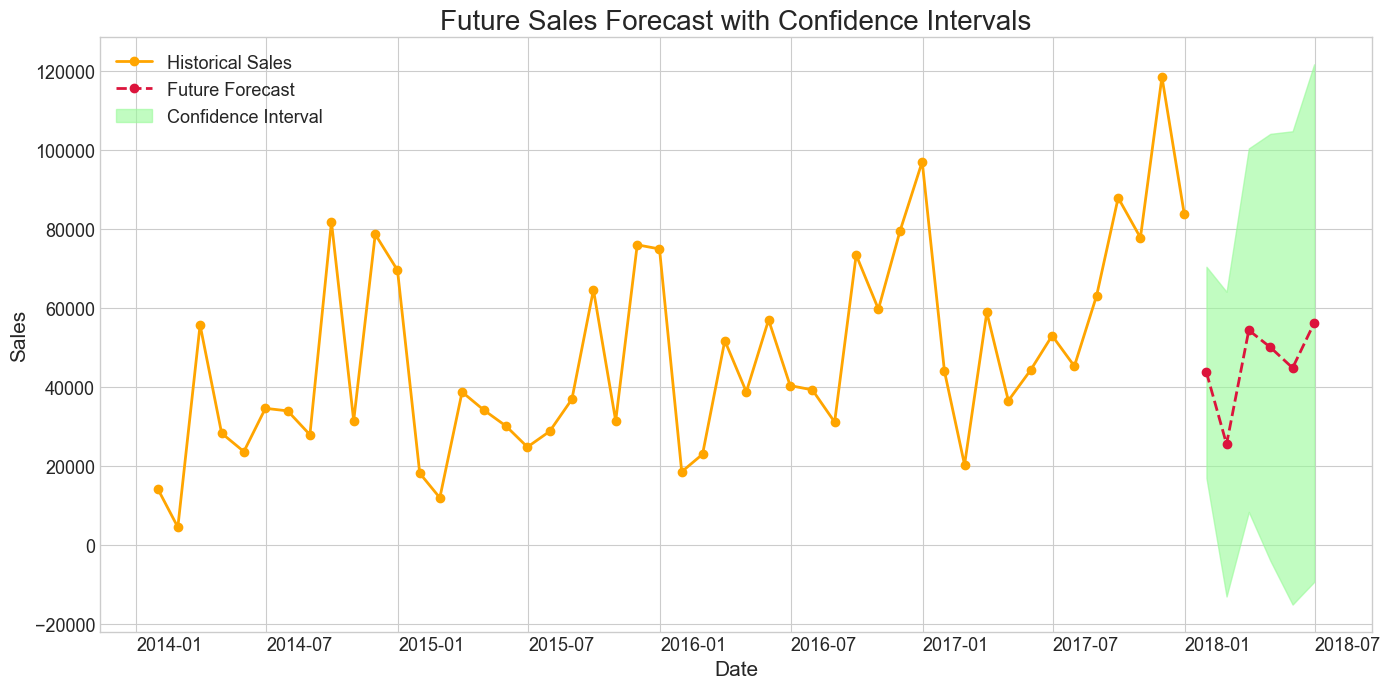

In [199]:
future_forecast = final_model_fit.get_forecast(steps=6)
future_predictions = future_forecast.predicted_mean
future_conf_int = future_forecast.conf_int()
future_lower = future_conf_int.iloc[:, 0]
future_upper = future_conf_int.iloc[:, 1]
plt.figure(figsize=(14,7))
plt.plot(monthly_sales.index, monthly_sales, marker='o',linewidth=2, label='Historical Sales', color='orange')
plt.plot(future_predictions.index, future_predictions, marker='o',linewidth=2, linestyle='dashed', label='Future Forecast',color='crimson')
plt.fill_between(future_lower.index, future_lower, future_upper, alpha=0.6, label='Confidence Interval', color='palegreen')
plt.title("Future Sales Forecast with Confidence Intervals",fontsize=20)
plt.xlabel("Date", fontsize=15)
plt.ylabel("Sales", fontsize=15)
plt.tight_layout()
plt.xticks(fontsize=13, ha='left')
plt.yticks(fontsize=13)
plt.grid(alpha=1)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

## ✅ Conclusion
### Summary

The project successfully applied SARIMA-based time-series forecasting to historical retail sales data.

Key achievements:
- identified trend and seasonal patterns
- improved forecasting accuracy using SARIMA
- generated future sales predictions
- evaluated model performance using MAE and RMSE

The project demonstrates the practical application of predictive analytics in retail sales forecasting.